In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
from google.colab import files
uploaded = files.upload()

Saving spotify dataset.csv to spotify dataset.csv


In [3]:
df = pd.read_csv('spotify dataset.csv')

df.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [4]:
df.shape

(32833, 23)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

In [6]:
df.describe()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000
mean,42.477081,0.654850,0.698619,5.374471,-6.719499,0.565711,0.107068,0.175334,0.084747,0.190176,0.510561,120.881132,225799.811622
std,24.984074,0.145085,0.180910,3.611657,2.988436,0.495671,0.101314,0.219633,0.224230,0.154317,0.233146,26.903624,59834.006182
min,0.000000,0.000000,0.000175,0.000000,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4000.000000
25%,24.000000,0.563000,0.581000,2.000000,-8.171000,0.000000,0.041000,0.015100,0.000000,0.092700,0.331000,99.960000,187819.000000
50%,45.000000,0.672000,0.721000,6.000000,-6.166000,1.000000,0.062500,0.080400,0.000016,0.127000,0.512000,121.984000,216000.000000
75%,62.000000,0.761000,0.840000,9.000000,-4.645000,1.000000,0.132000,0.255000,0.004830,0.248000,0.693000,133.918000,253585.000000
max,100.000000,0.983000,1.000000,11.000000,1.275000,1.000000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517810.000000


In [7]:
df.columns

Index(['track_id', 'track_name', 'track_artist', 'track_popularity',
       'track_album_id', 'track_album_name', 'track_album_release_date',
       'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_ms'],
      dtype='object')

In [8]:
df.isnull().sum()

,0
track_id,0
track_name,5
track_artist,5
track_popularity,0
track_album_id,0
track_album_name,5
track_album_release_date,0
playlist_name,0
playlist_id,0
playlist_genre,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.drop_duplicates()

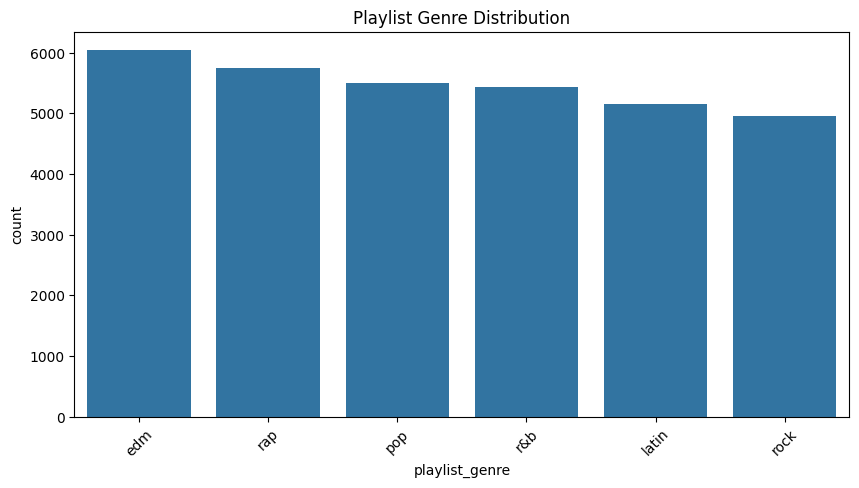

In [11]:
plt.figure(figsize=(10,5))

sns.countplot(data=df,
              x='playlist_genre',
              order=df['playlist_genre'].value_counts().index)

plt.xticks(rotation=45)

plt.title("Playlist Genre Distribution")

plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


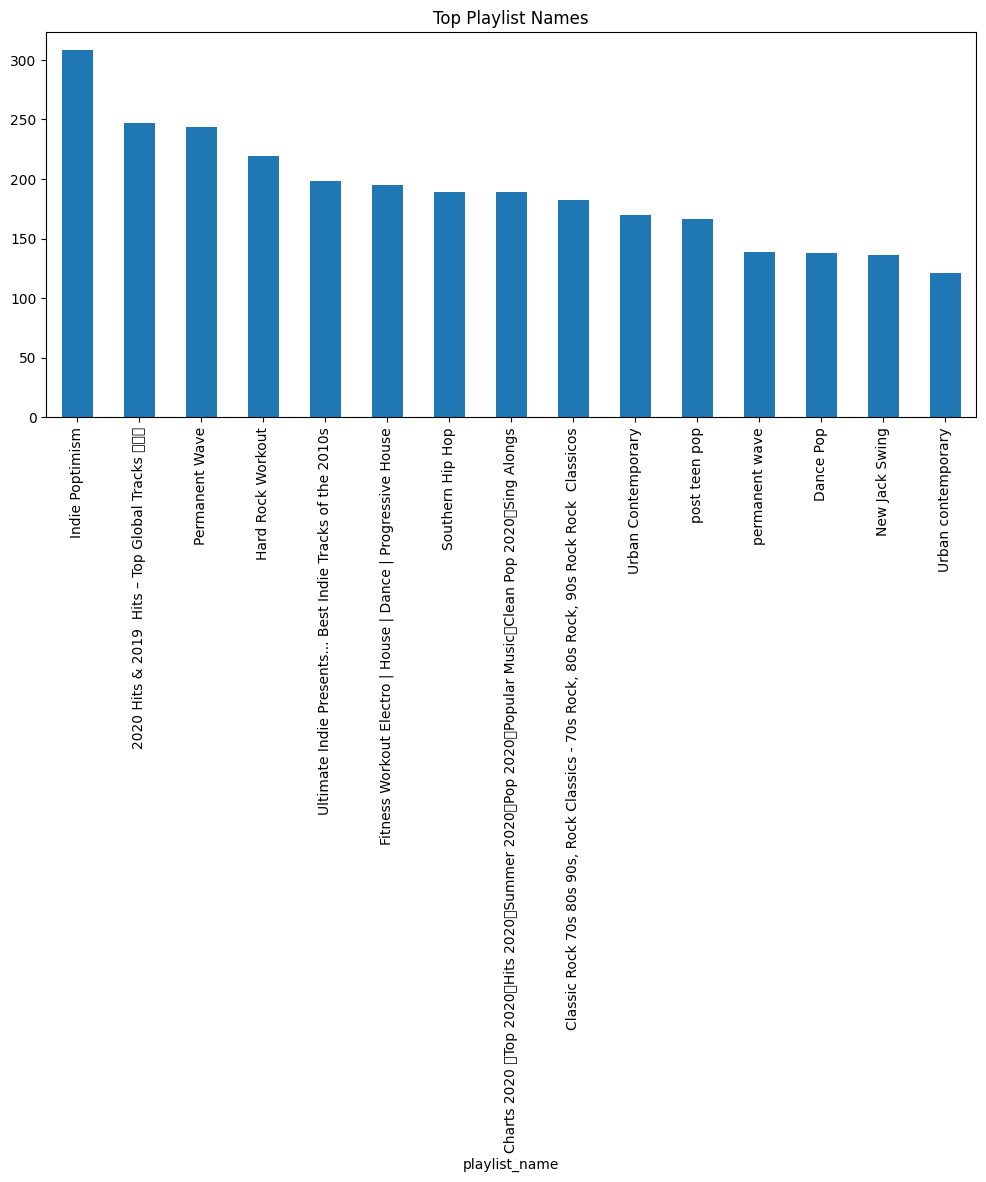

In [12]:
plt.figure(figsize=(12,5))

df['playlist_name'].value_counts().head(15).plot(kind='bar')

plt.title("Top Playlist Names")

plt.show()

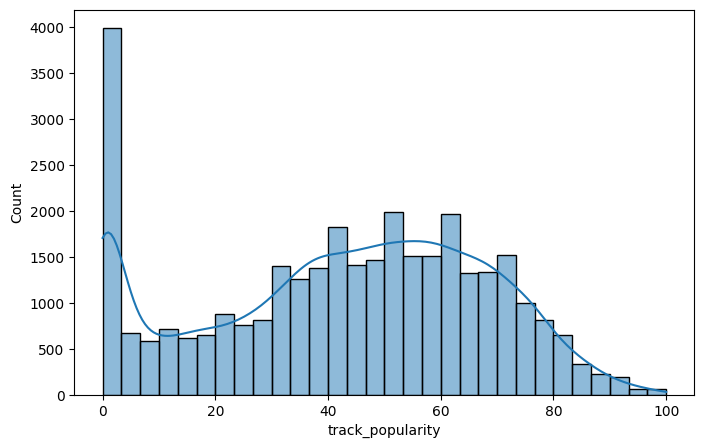

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df['track_popularity'],bins=30,kde=True)

plt.show()

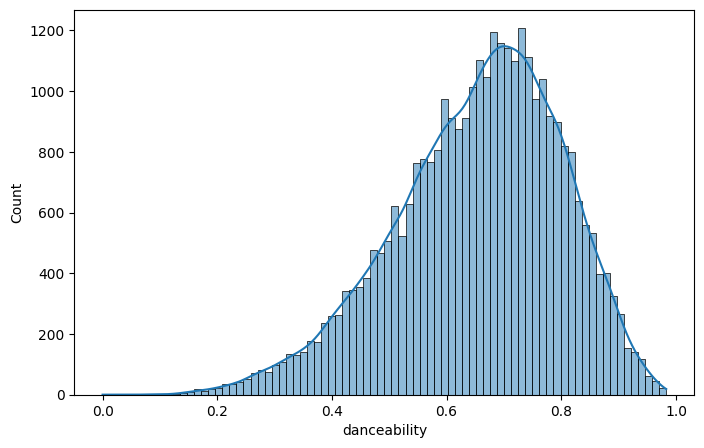

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df['danceability'],kde=True)

plt.show()

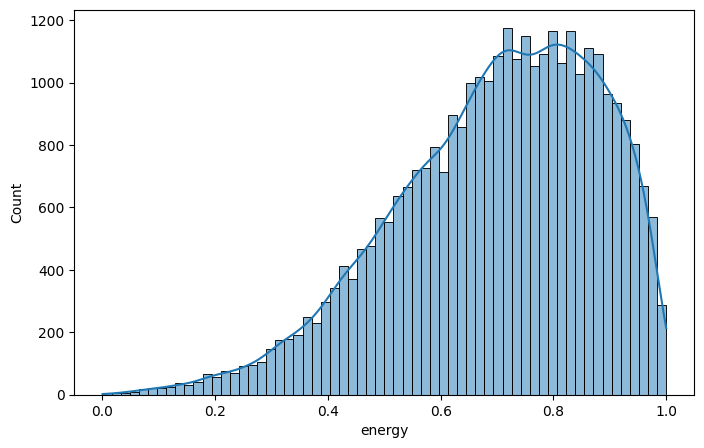

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df['energy'],kde=True)

plt.show()

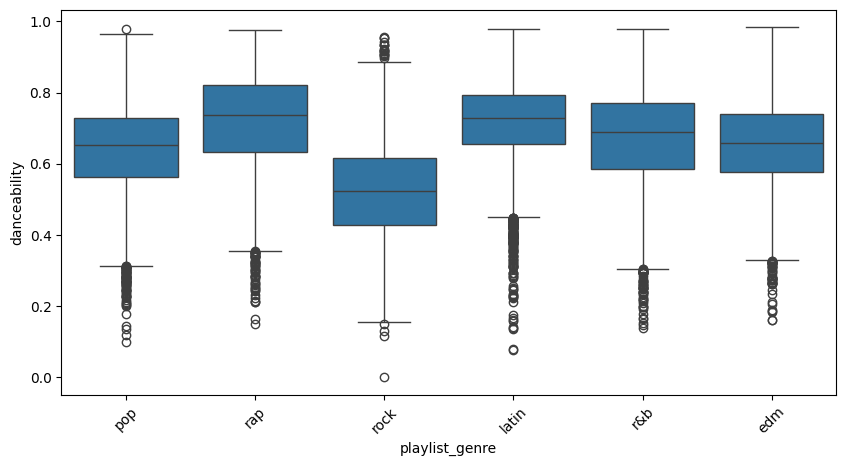

In [16]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df,
            x='playlist_genre',
            y='danceability')

plt.xticks(rotation=45)

plt.show()

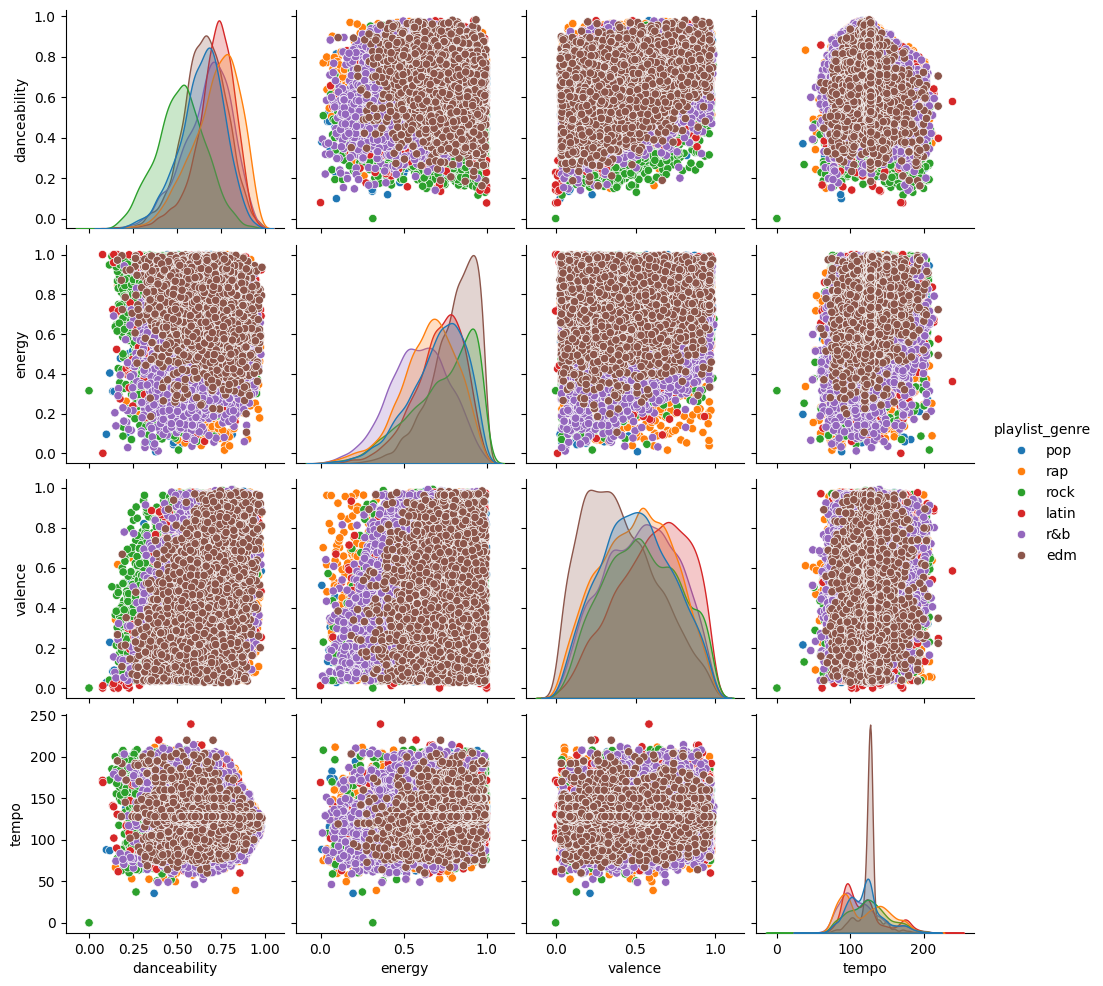

In [17]:
sns.pairplot(df[['danceability',
                 'energy',
                 'valence',
                 'tempo',
                 'playlist_genre']],
             hue='playlist_genre')

plt.show()

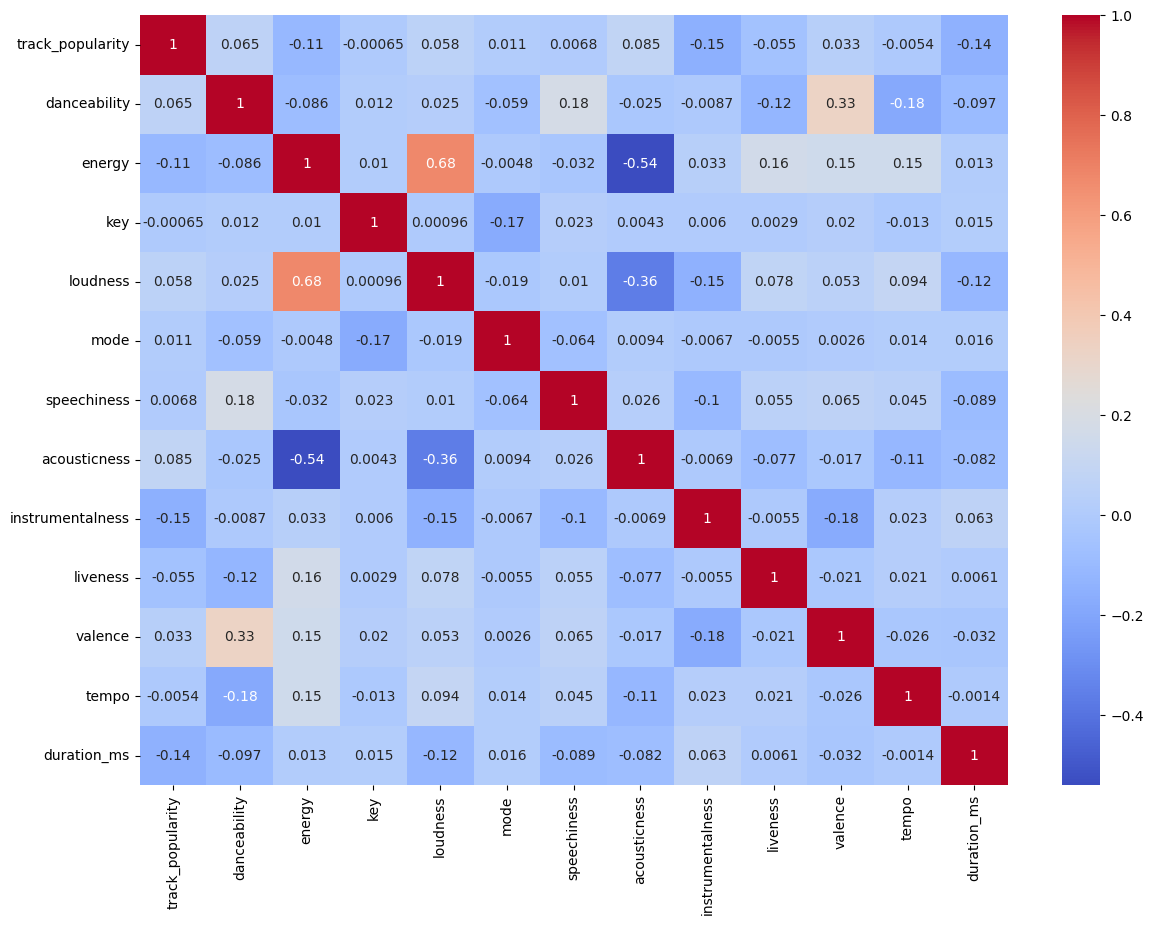

In [18]:
numeric = df.select_dtypes(include=np.number)

plt.figure(figsize=(14,10))

sns.heatmap(numeric.corr(),
            annot=True,
            cmap='coolwarm')

plt.show()

In [19]:
X = df[['danceability',
        'energy',
        'key',
        'loudness',
        'speechiness',
        'acousticness',
        'instrumentalness',
        'liveness',
        'valence',
        'tempo']]

In [20]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

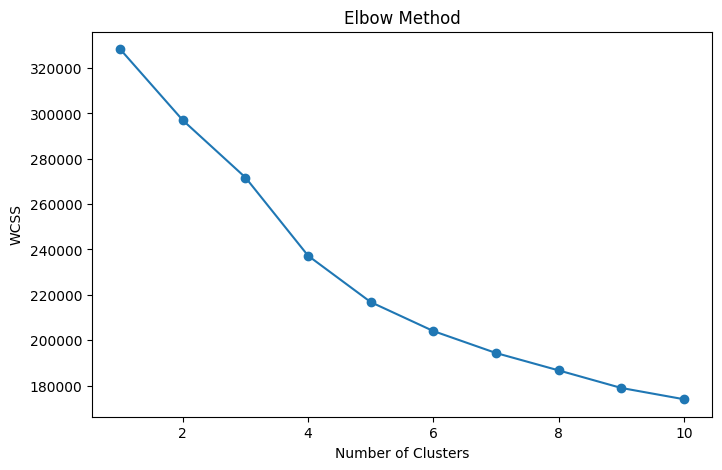

In [21]:
wcss=[]

for i in range(1,11):

    kmeans=KMeans(n_clusters=i,
                  random_state=42)

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [22]:
kmeans = KMeans(n_clusters=6,
                random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

In [23]:
score = silhouette_score(X_scaled,
                         df['Cluster'])

print("Silhouette Score:",score)

Silhouette Score: 0.13599647493696354


In [24]:
pca = PCA(n_components=2)

principal = pca.fit_transform(X_scaled)

df['PC1'] = principal[:,0]

df['PC2'] = principal[:,1]

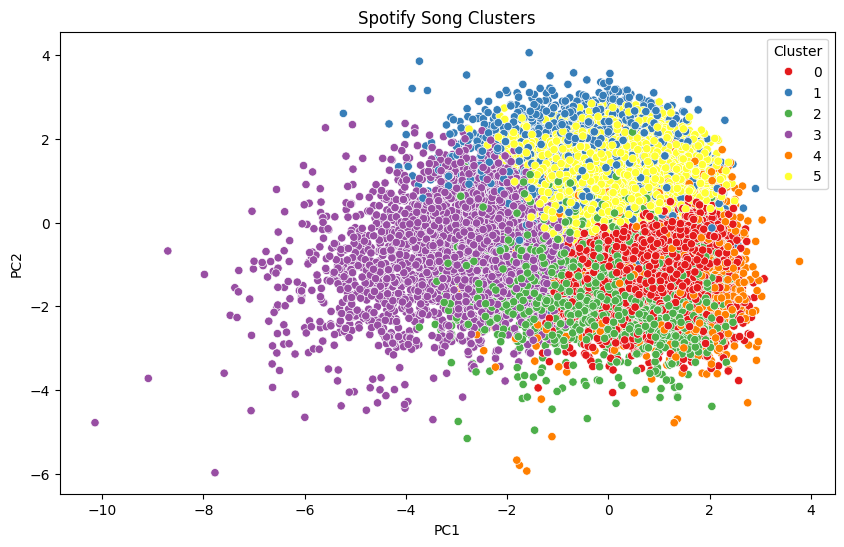

In [25]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=df,
                x='PC1',
                y='PC2',
                hue='Cluster',
                palette='Set1')

plt.title("Spotify Song Clusters")

plt.show()

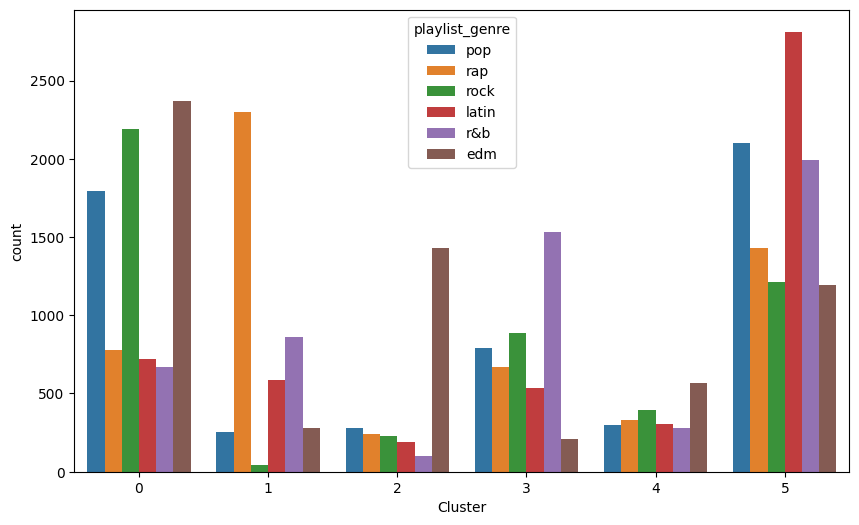

In [26]:
plt.figure(figsize=(10,6))

sns.countplot(data=df,
              x='Cluster',
              hue='playlist_genre')

plt.show()

In [27]:
df.groupby('Cluster')[['danceability',
                       'energy',
                       'valence',
                       'tempo',
                       'acousticness']].mean()

,danceability,energy,valence,tempo,acousticness
Cluster,,,,,
0,0.548256,0.789626,0.377105,132.455743,0.068429
1,0.725504,0.663232,0.544188,122.684202,0.184370
2,0.662201,0.780662,0.385407,124.995917,0.075508
3,0.604803,0.424385,0.391882,112.271352,0.522602
4,0.610707,0.780342,0.509913,121.652793,0.113152
5,0.739821,0.723537,0.682932,113.587241,0.142251


In [28]:
cluster = 2

recommend = df[df['Cluster']==cluster]

recommend[['track_name',
           'track_artist',
           'playlist_genre']].head(20)

,track_name,track_artist,playlist_genre
45,Heaven Can Wait - The Aston Shuffle Remix,Sia,pop
169,With You - LöKii Remix,Kaskade,pop
202,Dreams Of You (feat. Rae Morris),Icarus,pop
342,Penny,Dimitri Vangelis & Wyman,pop
350,Shades Of Voices (Original Mix),PULLER,pop
353,Spirit Of Freedom,Dropgun,pop
361,Skyline,Catiso,pop
362,Callin' - Extended Mix,Lush & Simon,pop
368,Mercury,Catiso,pop
376,Pure Gold,oomiee,pop
